In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [4]:
# Define the column names based on the documentation
movie_columns = [
    "movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
ratings_columns = ["user_id", "item_id", "rating", "timestamp"]
user_columns = ["user_id", "age", "gender", "occupation", "zip_code"]



# Read the file and apply column names


In [5]:
df_rating = pd.read_csv("../data/raw/movie/u.data",sep='\t', encoding='latin-1', header=None, names=ratings_columns)
df_movie = pd.read_csv("../data/raw/movie/u.item", sep='|', encoding='latin-1', header=None, names=movie_columns)
df_user = pd.read_csv("../data/raw/movie/u.user",sep='|', encoding='latin-1', header=None, names=user_columns)


In [6]:
print('Movie data nulls:-\n',df_movie.info())
print()
print('Rating data nulls:-\n',df_rating.info())
print()
print('Users data nulls:-\n',df_user.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   IMDb_URL            1679 non-null   object 
 5   unknown             1682 non-null   int64  
 6   Action              1682 non-null   int64  
 7   Adventure           1682 non-null   int64  
 8   Animation           1682 non-null   int64  
 9   Children's          1682 non-null   int64  
 10  Comedy              1682 non-null   int64  
 11  Crime               1682 non-null   int64  
 12  Documentary         1682 non-null   int64  
 13  Drama               1682 non-null   int64  
 14  Fantasy             1682 non-null   int64  
 15  Film-Noir           1682 non-null   int64  
 16  Horror

In [7]:
df_movie.drop(['video_release_date'], axis=1, inplace=True)

In [8]:
df_movie.dropna(inplace=True)


In [9]:
df_movie.head()

,movie_id,title,release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children's,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [10]:
df_user.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [11]:
df_rating.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [12]:
print('movie data nulls:-\n',df_movie.isnull().sum())
print()
print('Rating movie data nulls:-\n',df_rating.isnull().sum())
print()
print('Users movie data nulls:-\n',df_user.isnull().sum())

movie data nulls:-
 movie_id        0
title           0
release_date    0
IMDb_URL        0
unknown         0
Action          0
Adventure       0
Animation       0
Children's      0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

Rating movie data nulls:-
 user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Users movie data nulls:-
 user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64


In [13]:
# Check for total number of duplicate rows
duplicates_book = df_movie.duplicated().sum()
print(f"Duplicate rows: {duplicates_book}")
duplicates_rating = df_user.duplicated().sum()
print(f"Duplicate rows: {duplicates_rating}")
duplicates_user = df_rating.duplicated().sum()
print(f"Duplicate rows: {duplicates_user}")


Duplicate rows: 0
Duplicate rows: 0
Duplicate rows: 0


# Rating Table

In [15]:
df_rating.describe()

,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [14]:
unique_ratings = df_rating['rating'].value_counts()
print("Rating distribution:")
print(unique_ratings)

Rating distribution:
rating
4    34174
3    27145
5    21201
2    11370
1     6110
Name: count, dtype: int64


- we can see that the rating 4 is having the most of the counts in the dataset we can say that most of the user rated the rating 4.
- Less user selected rating 1.
- By this we can say that the movies present in the dataset are mostly between better and best as most people liked the movies.

# Movie table

In [16]:
df_movie.describe()

,movie_id,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000,1679.000000
mean,841.226325,0.000596,0.148898,0.080405,0.025015,0.072662,0.300774,0.064920,0.029780,0.431209,0.013103,0.014294,0.054795,0.033353,0.036331,0.147111,0.060155,0.149494,0.042287,0.016081
std,485.599531,0.024405,0.356094,0.272000,0.156217,0.259659,0.458731,0.246457,0.170029,0.495393,0.113750,0.118736,0.227647,0.179611,0.187169,0.354322,0.237844,0.356681,0.201303,0.125825
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,421.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,841.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1260.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1682.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Corrupted value in the movie table with the difference genere cols.

In [20]:
# Step 1: Get genre columns (assuming genre columns start from index 5)
genre_cols = df_movie.columns[5:]

# Step 2: Initialize counter for total corrupted entries
total_corrupted = 0

# Step 3: Loop through each genre column
for col in genre_cols:
    # Find corrupted values (not 0 or 1)
    corrupted = ~df_movie[col].isin([0, 1])
    
    # Count corrupted values
    count = corrupted.sum()
    total_corrupted += count
    
    # Print count per column if corrupted
    if count > 0:
        print(f"{col}: {count} corrupted entries")
        
        # Replace corrupted values with the mode (0 or 1)
        mode_val = df_movie[col].mode()[0]
        df_movie.loc[corrupted, col] = mode_val

# Step 4: Print total
print(f"\nTotal corrupted genre values replaced: {total_corrupted}")



Total corrupted genre values replaced: 0


- There is no corrupted data.

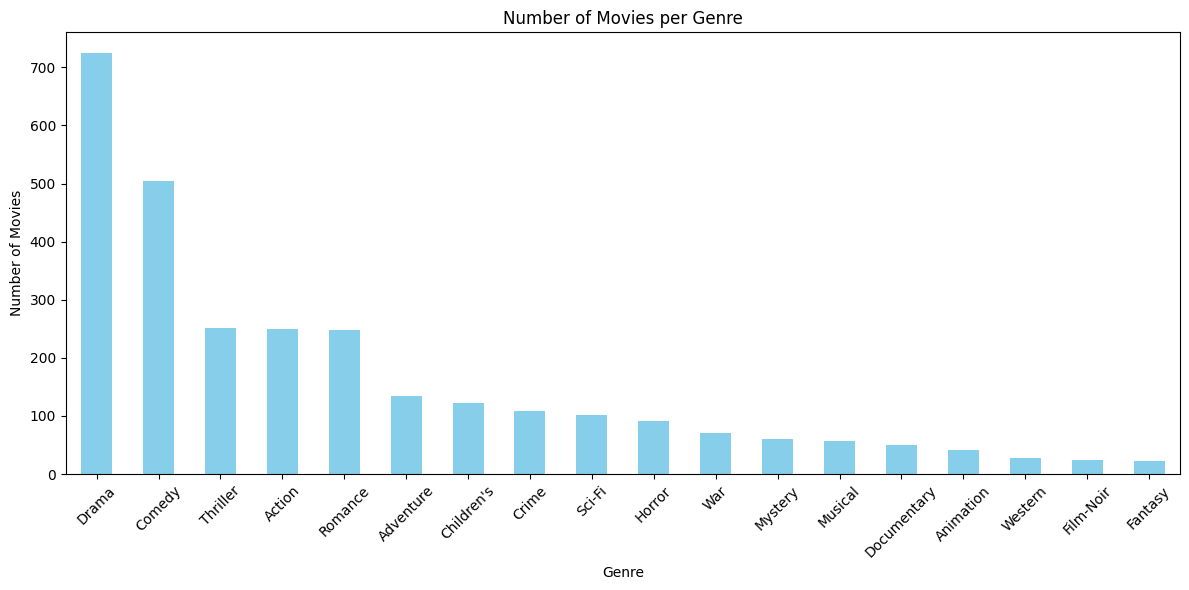

In [19]:
genre_columns = df_movie.columns[5:]

# Sum each genre column to get the total number of movies in each genre
genre_counts = df_movie[genre_columns].sum().sort_values(ascending=False)

# Plot the bar graph
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- From this we can see that Drama is the genre with the most of the flag marked by the user.
- Most of the movies comes under the drama genre. 
- Fantasy movie are least in the dataset means many movies can be either real based or can happend in the reality based movies.

# User Table

In [21]:
df_user.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213



Age summary statistics:
count    943.000000
mean      34.051962
std       12.192740
min        7.000000
25%       25.000000
50%       31.000000
75%       43.000000
max       73.000000
Name: age, dtype: float64

Age group distribution:
age_group
Under 18     36
18-24       198
25-34       310
35-49       274
50-64       113
65+          12
Name: count, dtype: int64


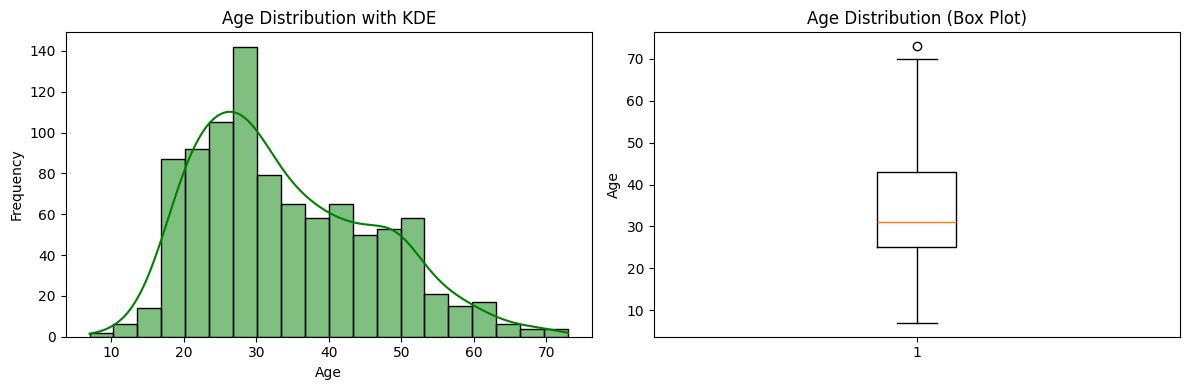

In [28]:
print("\nAge summary statistics:")
print(df_user['age'].describe())

# 3. Create age groups/bins for better visualization
age_bins = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['Under 18', '18-24', '25-34', '35-49', '50-64', '65+']
df_user['age_group'] = pd.cut(df_user['age'], bins=age_bins, labels=age_labels, right=False)

age_group_distribution = df_user['age_group'].value_counts().sort_index()
print("\nAge group distribution:")
print(age_group_distribution)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_user['age'], bins=20, kde=True, edgecolor='black', color='green')
plt.title('Age Distribution with KDE')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(df_user['age'])
plt.title('Age Distribution (Box Plot)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

- From this we can see that 25-34 age group people are more in the dataset.
- The graphs shows is the right skewed which shows that the majority of the user are of less than the age 30.
 

## Invalid Gender


In [29]:
# Check for gender values not equal to 'M' or 'F'
invalid_genders = df_user[~df_user['gender'].isin(['M', 'F'])]

# Show the result
print(f"Invalid gender entries found: {len(invalid_genders)}")
print(invalid_genders)


Invalid gender entries found: 0
Empty DataFrame
Columns: [user_id, age, gender, occupation, zip_code, age_group]
Index: []


Occupation distribution:
occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31
artist            28
technician        27
marketing         26
entertainment     18
healthcare        16
retired           14
lawyer            12
salesman          12
none               9
homemaker          7
doctor             7
Name: count, dtype: int64


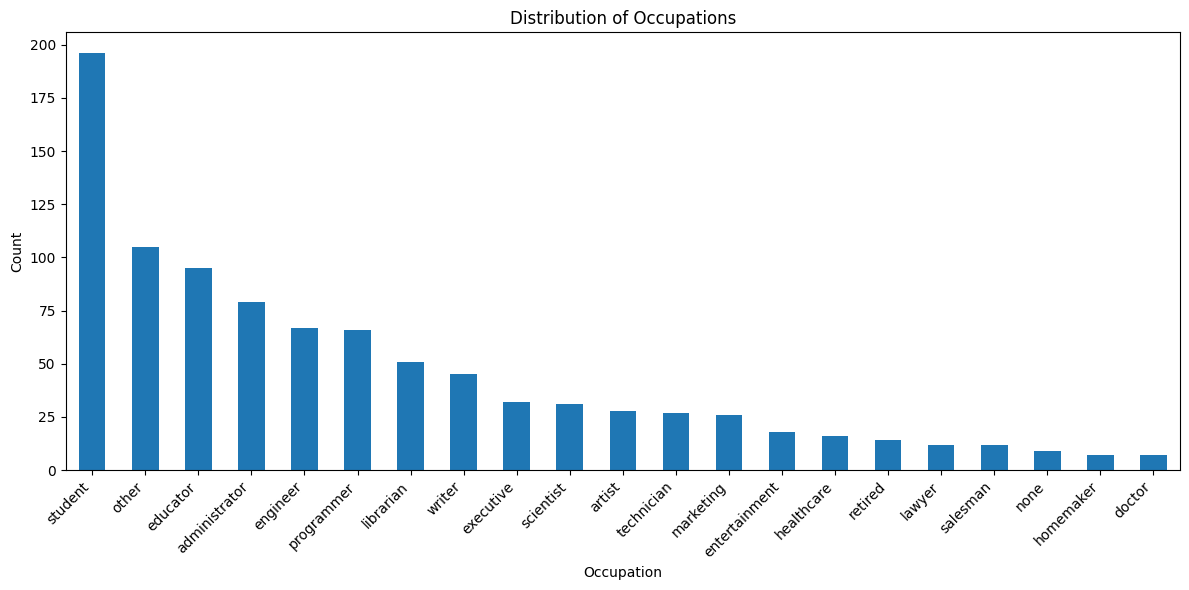

In [30]:
# Get unique occupations and their counts
occupation_counts = df_user['occupation'].value_counts()
print("Occupation distribution:")
print(occupation_counts)
plt.figure(figsize=(12, 6))

# Bar plot of occupations
occupation_counts.plot(kind='bar')
plt.title('Distribution of Occupations')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Students form the largest group (196).
- Educators and administrators show strong presence, pointing to professional engagement.
- Creative roles like writers, artists, and librarians are also notably present.
- Retired users and homemakers are fewer, showing limited reach in older age groups.

# Malti-Variate Analysis

A user gave a rating, but that user_id doesn't exist in the user table → means it's an invalid or unregistered user.

You want to keep only ratings from valid users → ✅ INNER JOIN between df_ratings and df_user.

But you still want to keep all movies, even if some movies haven’t been rated → ✅ LEFT JOIN on movie.

Join Step	Purpose
ratings INNER user	Remove ratings from non-existent/unregistered users ✅
LEFT JOIN movie	Keep movie metadata for all movies, even unrated ones ✅




In [32]:
# Step 1: Merge ratings with movies — INNER (only rated movies)
df_ratings_movies = df_rating.merge(df_movie, left_on='item_id', right_on='movie_id', how='inner')

# Step 2: Merge with users — INNER (only known users who rated)
df_analysis = df_ratings_movies.merge(df_user, on='user_id', how='inner')


##  Genre Popularity by Rating Count

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_58692\393041958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_58692\393041958.py:19: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


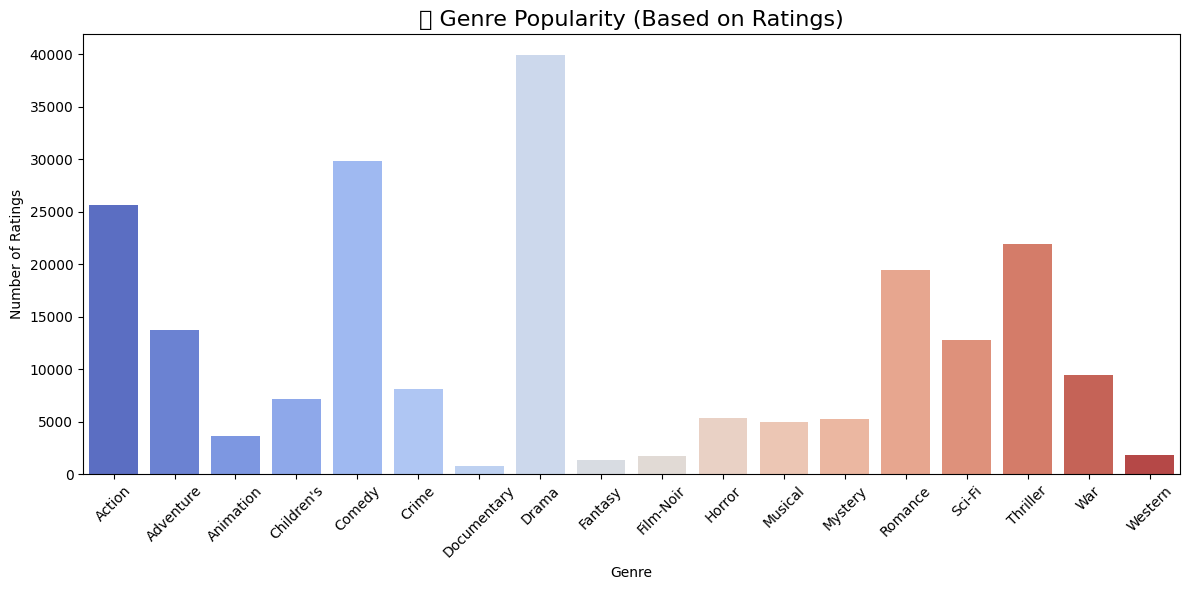

In [33]:
genre_cols = df_movie.columns[5:]

# Count how many times each genre appears in ratings
genre_rating_counts = {
    genre: df_analysis[df_analysis[genre] == 1].shape[0]
    for genre in genre_cols
}

plt.figure(figsize=(12, 6))
sns.barplot(
    x=list(genre_rating_counts.keys()),
    y=list(genre_rating_counts.values()),
    palette='coolwarm'
)
plt.title("🎬 Genre Popularity (Based on Ratings)", fontsize=16)
plt.ylabel("Number of Ratings")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Most of the ratings are provided to the Drama movies, followed by the action and comedy
- 

##  Average Rating by Genre

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_58692\810476714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_58692\810476714.py:16: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


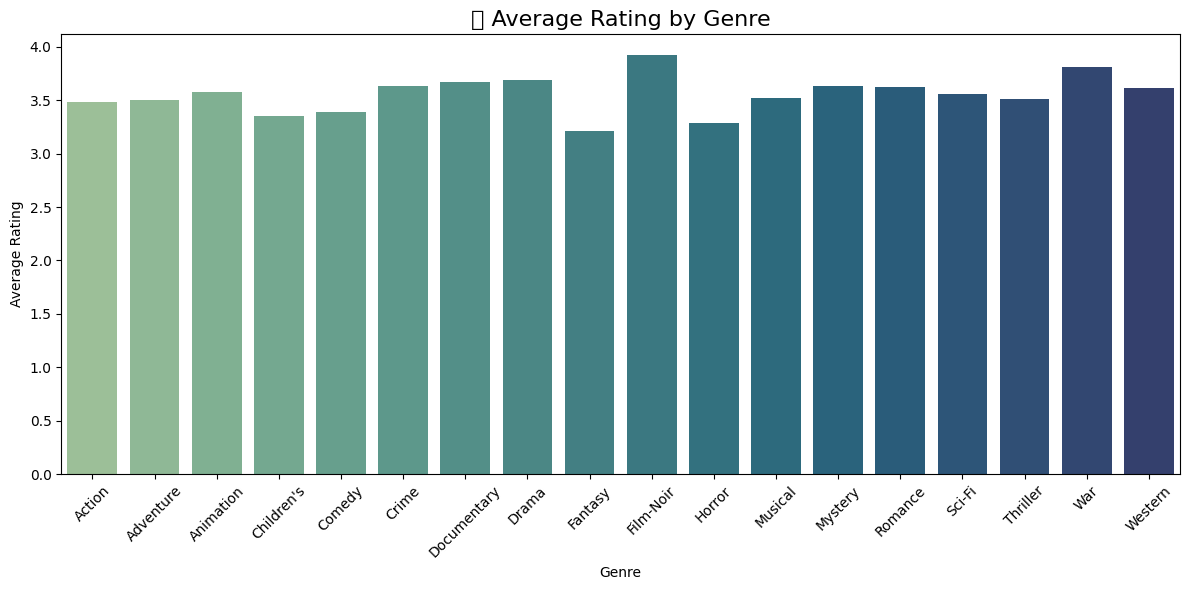

In [34]:
genre_avg_rating = {
    genre: df_analysis[df_analysis[genre] == 1]['rating'].mean()
    for genre in genre_cols
}

plt.figure(figsize=(12, 6))
sns.barplot(
    x=list(genre_avg_rating.keys()),
    y=list(genre_avg_rating.values()),
    palette='crest'
)
plt.title("⭐ Average Rating by Genre", fontsize=16)
plt.ylabel("Average Rating")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- From this we can see that the average rating of the all genre movie is almost same lies in the range of the 3-4.
- Film-Noir category is havin the highest average rating.

## Average Rating by Age Group

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_58692\2834120009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analysis, x='age_group', y='rating', palette='viridis')
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127874 (\N{BIRTHDAY CAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


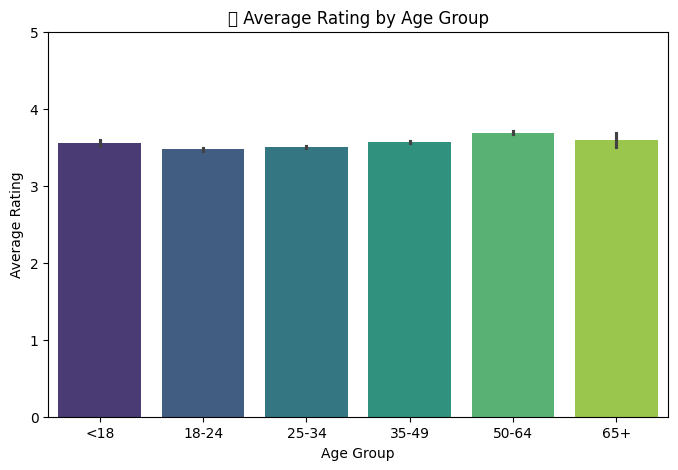

In [36]:
age_bins = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-49', '50-64', '65+']
df_analysis['age_group'] = pd.cut(df_analysis['age'], bins=age_bins, labels=age_labels)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_analysis, x='age_group', y='rating', palette='viridis')
plt.title("🎂 Average Rating by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()


## Heatmap: Rating by Age Group and Gender

C:\Users\aditya.kaushal\AppData\Local\Temp\ipykernel_58692\1291077575.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df_analysis.pivot_table(
e:\GitHub Repo's\Multi_domain_Recommendation\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


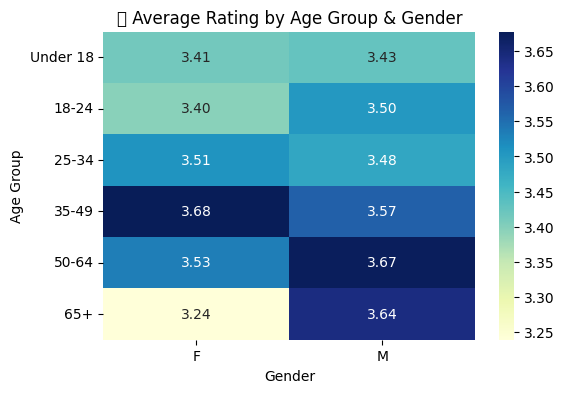

In [35]:
heatmap_data = df_analysis.pivot_table(
    index='age_group', columns='gender', values='rating', aggfunc='mean'
)

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("🔥 Average Rating by Age Group & Gender")
plt.ylabel("Age Group")
plt.xlabel("Gender")
plt.show()


In [38]:
base_path = r"E:\GitHub Repo's\Multi_domain_Recommendation\data\processed"

# Define datasets per domain
datasets = {
    "movie": {
        "movie_user":df_user,
        "movie_info": df_movie,
        "movie_rating": df_rating
    }
}

# Save each table in its domain folder
for domain, tables in datasets.items():
    domain_path = os.path.join(base_path, domain)
    os.makedirs(domain_path, exist_ok=True)
    
    for table_name, df in tables.items():
        file_path = os.path.join(domain_path, f"{table_name}.csv")
        df.to_csv(file_path, index=False)
        print(f"✅ Saved: {file_path}")


✅ Saved: E:\GitHub Repo's\Multi_domain_Recommendation\data\processed\movie\movie_user.csv
✅ Saved: E:\GitHub Repo's\Multi_domain_Recommendation\data\processed\movie\movie_info.csv
✅ Saved: E:\GitHub Repo's\Multi_domain_Recommendation\data\processed\movie\movie_rating.csv
